# Seattle House Price Prediction in Python

**Objective:** Predict house prices in Seattle based on property features.

**Dataset:** Contains house listings with features including:
- `beds` (number of bedrooms)  
- `baths` (number of bathrooms; 0.5 represents a half-bath)  
- `size` (total floor area of the property)  
- `size_units` (unit of measurement, e.g., sqft)  
- `lot_size` (total land area)  
- `lot_size_units` (unit of lot_size, e.g., sqft, acre)  
- `zip_code` (postal code in Seattle)  
- `price` (sale price in USD)

**Useful Fact:**  
1 acre = 43,560 sqft

**Approach:**
1. Importing Python libraries and loading data
2. Data Cleaning & Preprocessing  
3. Feature Engineering  
4. Exploratory Data Analysis (EDA)  
5. Feature Scaling and Data Preparation  
6. Model Training (Linear Regression, Ridge, Lasso & Random Forest)  
7. Hyperparameter Tuning and Model Evaluation 
8. Feature Importance Visualization  
9. Test Set Predictions  


<u>**Step 1: Importing Python libraries and loading data**</u>

In [4]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
sns.set_style('whitegrid')

In [5]:
# Load data
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

In [6]:
df_train.head() # seeing the first 5 rows of the df_train

,beds,baths,size,size_units,lot_size,lot_size_units,zip_code,price
0,3,2.5,2590.0,sqft,6000.00,sqft,98144,795000.0
1,4,2.0,2240.0,sqft,0.31,acre,98106,915000.0
2,4,3.0,2040.0,sqft,3783.00,sqft,98107,950000.0
3,4,3.0,3800.0,sqft,5175.00,sqft,98199,1950000.0
4,2,2.0,1042.0,sqft,NaN,NaN,98102,950000.0


In [7]:
df_test.head() # seeing the first 5 rows of the df_test

,beds,baths,size,size_units,lot_size,lot_size_units,zip_code,price
0,3,3.0,2850.0,sqft,4200.00,sqft,98119,1175000.0
1,4,5.0,3040.0,sqft,5002.00,sqft,98106,1057500.0
2,3,1.0,1290.0,sqft,6048.00,sqft,98125,799000.0
3,3,2.0,2360.0,sqft,0.28,acre,98188,565000.0
4,3,3.5,1942.0,sqft,1603.00,sqft,98107,1187000.0


**Summary of what has been done in this section:**
- Import all required Python libraries for data manipulation, visualization, and machine learning.
- Load training and test datasets into pandas DataFrames.
- Display the first 5 rows of each dataset to understand the features and data types.



<u>**Step 2: Data Cleaning and Preprocessing**</u>

In [10]:
# Round numeric columns in df_train
for col in df_train.select_dtypes(include=np.number).columns:
    df_train[col] = df_train[col].round(1)

# Round numeric columns in df_test
for col in df_test.select_dtypes(include=np.number).columns:
    df_test[col] = df_test[col].round(1)

In [11]:
df_train.isnull().sum() # checking for null values

beds                0
baths               0
size                0
size_units          0
lot_size          347
lot_size_units    347
zip_code            0
price               0
dtype: int64

In [12]:
df_test.isnull().sum() # checking for null values

beds               0
baths              0
size               0
size_units         0
lot_size          77
lot_size_units    77
zip_code           0
price              0
dtype: int64

From the current status of the dataframes - it seems like **lot_size** and **lot_size_units** in both the **df_train** and **df_test** have null values. 

Additionally there seems to be some sort of **inconsistency** whether the **lot_size_units** should be in **sqft** or **acre** and this affects the values in **lot_size**

In [15]:
# Handle missing values & convert units
for df in [df_train, df_test]:
    
    # Fill missing lot_size_units with mode
    df['lot_size_units'] = df['lot_size_units'].fillna(df['lot_size_units'].mode()[0])
    
    # Fill missing lot_size with median
    df['lot_size'] = df['lot_size'].fillna(df['lot_size'].median())
    
    # Convert acres to sqft
    df.loc[df['lot_size_units'] == 'acre', 'lot_size'] *= 43560

    # Standardize unit
    df['lot_size_units'] = 'sqft'

In [16]:
# removing zip_code from our dataframe 
df_train = df_train.drop(columns=['zip_code'])
df_test = df_test.drop(columns=['zip_code'])

In [17]:
df_train.head()

,beds,baths,size,size_units,lot_size,lot_size_units,price
0,3,2.5,2590.0,sqft,6000.0,sqft,795000.0
1,4,2.0,2240.0,sqft,13068.0,sqft,915000.0
2,4,3.0,2040.0,sqft,3783.0,sqft,950000.0
3,4,3.0,3800.0,sqft,5175.0,sqft,1950000.0
4,2,2.0,1042.0,sqft,4000.0,sqft,950000.0


In [18]:
df_test.head()

,beds,baths,size,size_units,lot_size,lot_size_units,price
0,3,3.0,2850.0,sqft,4200.0,sqft,1175000.0
1,4,5.0,3040.0,sqft,5002.0,sqft,1057500.0
2,3,1.0,1290.0,sqft,6048.0,sqft,799000.0
3,3,2.0,2360.0,sqft,13068.0,sqft,565000.0
4,3,3.5,1942.0,sqft,1603.0,sqft,1187000.0


In [19]:
print(df_train.isnull().sum()) # checking null values after data cleaning

beds              0
baths             0
size              0
size_units        0
lot_size          0
lot_size_units    0
price             0
dtype: int64


In [20]:
print(df_test.isnull().sum()) # checking null values after data cleaning

beds              0
baths             0
size              0
size_units        0
lot_size          0
lot_size_units    0
price             0
dtype: int64


**Summary of what has been done in this section:**
- Fill missing values for lot_size_units with the most common value (mode).  
- Fill missing values for lot_size with the median to avoid skewing the data.  
- Convert lot_size from acres to square feet for consistency (1 acre = 43,560 sqft).  
- Drop zip_code to simplify modeling; zip codes can be used later if needed.  
- After these steps, there should be no missing values in the datasets.


<u>**Step 3. Feature Engineering**</u>

In [23]:
# Interaction feature: house size * lot size - combines house size and lot size into one metric
# bigger houses on bigger lots are generally more expensive
df_train['size_lot_interaction'] = (df_train['size'] * df_train['lot_size']).round(1)
df_test['size_lot_interaction'] = (df_test['size'] * df_test['lot_size']).round(1)

# Ratio feature: beds per bath
# Formula: beds / (bath + 0.5)
# Purpose: measures property layout efficiency (number of bedrooms per bathroom)
# Adding 0.5 ensures stability and avoids division by 0
df_train['beds_per_bath'] = (df_train['beds'] / (df_train['baths'] + 0.5)).round(1)
df_test['beds_per_bath'] = (df_test['beds'] / (df_test['baths'] + 0.5)).round(1)

# lot size per bedroom
# Formula: lot_size / beds
# Purpose: measures how much land area each bedroom gets - indicating spaciousness
df_train['lot_per_bed'] = (df_train['lot_size'] / df_train['beds']).round(1)
df_test['lot_per_bed'] = (df_test['lot_size'] / df_test['beds']).round(1)

# Preview the updated datasets

print("This is df_train below:")
display(df_train.head())

print("This is df_test below:")
display(df_test.head())

This is df_train below:


,beds,baths,size,size_units,lot_size,lot_size_units,price,size_lot_interaction,beds_per_bath,lot_per_bed
0,3,2.5,2590.0,sqft,6000.0,sqft,795000.0,15540000.0,1.0,2000.0
1,4,2.0,2240.0,sqft,13068.0,sqft,915000.0,29272320.0,1.6,3267.0
2,4,3.0,2040.0,sqft,3783.0,sqft,950000.0,7717320.0,1.1,945.8
3,4,3.0,3800.0,sqft,5175.0,sqft,1950000.0,19665000.0,1.1,1293.8
4,2,2.0,1042.0,sqft,4000.0,sqft,950000.0,4168000.0,0.8,2000.0


This is df_test below:


,beds,baths,size,size_units,lot_size,lot_size_units,price,size_lot_interaction,beds_per_bath,lot_per_bed
0,3,3.0,2850.0,sqft,4200.0,sqft,1175000.0,11970000.0,0.9,1400.0
1,4,5.0,3040.0,sqft,5002.0,sqft,1057500.0,15206080.0,0.7,1250.5
2,3,1.0,1290.0,sqft,6048.0,sqft,799000.0,7801920.0,2.0,2016.0
3,3,2.0,2360.0,sqft,13068.0,sqft,565000.0,30840480.0,1.2,4356.0
4,3,3.5,1942.0,sqft,1603.0,sqft,1187000.0,3113026.0,0.8,534.3


**Summary of what has been done in this section:**

- **size_lot_interaction**: Combines `size` and `lot_size` to capture the joint impact of house and land size on price.  
- **beds_per_bath**: Measures the number of bedrooms per bathroom to capture layout efficiency; adding 0.5 prevents division errors and smooths ratios.  
- **lot_per_bed**: Shows how much land area each bedroom has, providing an indication of spaciousness.  

These engineered features provide additional insights to the model and can improve predictive performance.


<u>**Step 4. Exploratory Data Analysis (EDA)**</u>

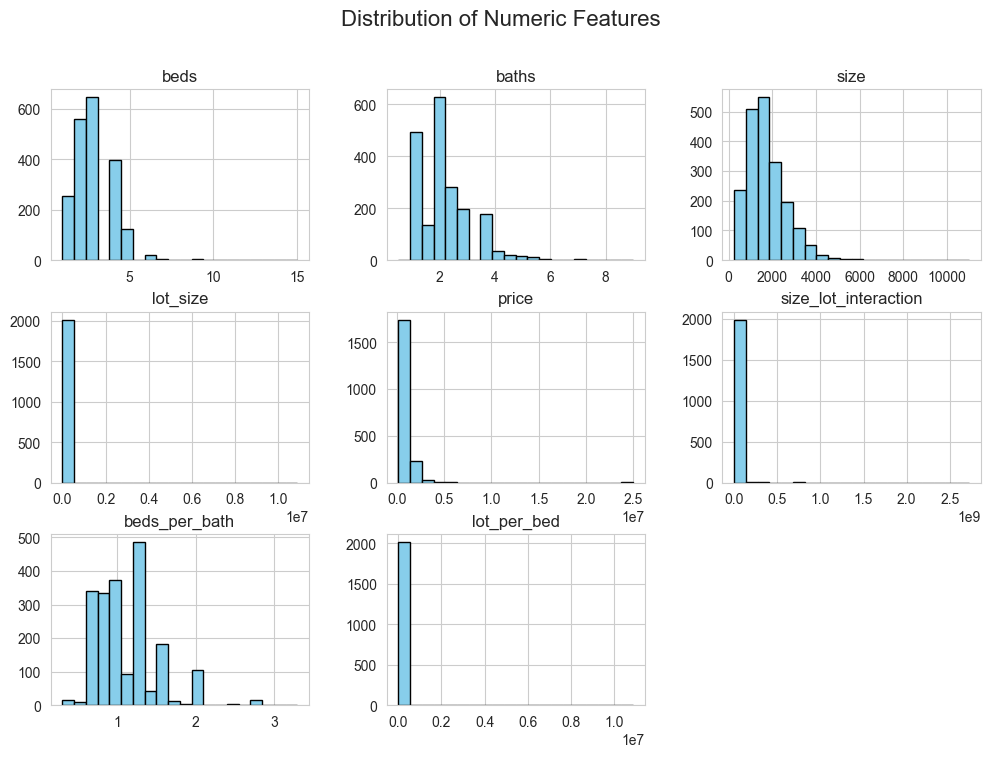

In [26]:
numeric_cols = ['beds', 'baths', 'size', 'lot_size', 'price', 
                'size_lot_interaction', 'beds_per_bath', 'lot_per_bed']

# Plot histograms for each numeric feature
df_train[numeric_cols].hist(bins=20, figsize=(12,8), color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Numeric Features', fontsize=16)
plt.show()


- Histograms show the distribution of numeric features.

- We can identify skewness, outliers, or unusual values.

- Features include both original numeric variables (beds, baths, size, lot_size, price) and engineered features (size_lot_interaction, beds_per_bath, lot_per_bed).

- Some features (like lot_size, price, size_lot_interaction, lot_per_bed) are heavily skewed, so their distributions are compressed on the left side of the histogram.

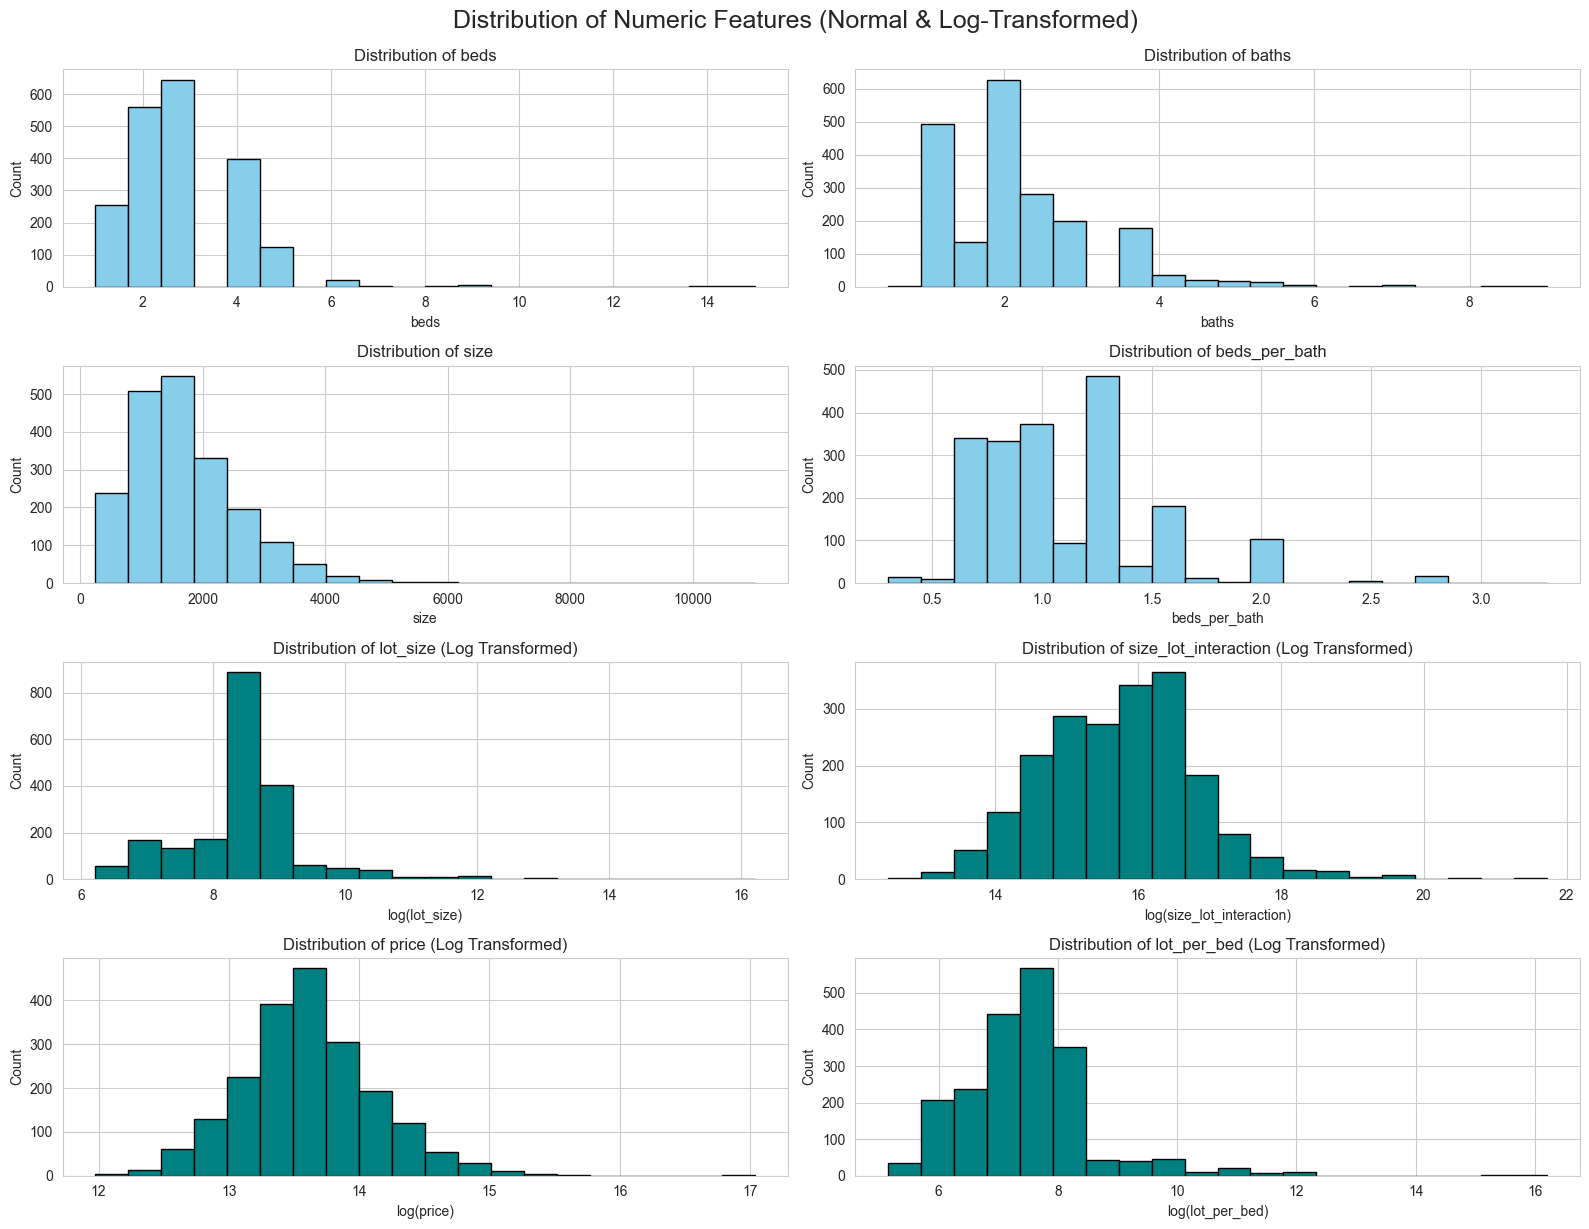

In [28]:
normal_features = ['beds', 'baths', 'size', 'beds_per_bath']
skewed_features = ['lot_size', 'size_lot_interaction', 'price', 'lot_per_bed']

# Create figure
plt.figure(figsize=(16,12))

# Plot normal features
for i, col in enumerate(normal_features, 1):
    plt.subplot(4, 2, i)
    plt.hist(df_train[col], bins=20, color='skyblue', edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(f'Distribution of {col}')

# Plot skewed features (log transformed)
for i, col in enumerate(skewed_features, len(normal_features)+1):
    plt.subplot(4, 2, i)
    plt.hist(np.log1p(df_train[col]), bins=20, color='teal', edgecolor='black')
    plt.xlabel(f'log({col})')
    plt.ylabel('Count')
    plt.title(f'Distribution of {col} (Log Transformed)')

plt.tight_layout()
plt.suptitle("Distribution of Numeric Features (Normal & Log-Transformed)", fontsize=18, y=1.02)
plt.show()

- Normal features are plotted without transformation
  
- Skewed features are log-transformed using np.log1p() to better visualize their distributions.

- Log transformation helps:

- Compress extreme values (outliers)

- Spread small values to make the histogram easier to interpret

- Make distributions closer to normal, which benefits some models like Linear Regression

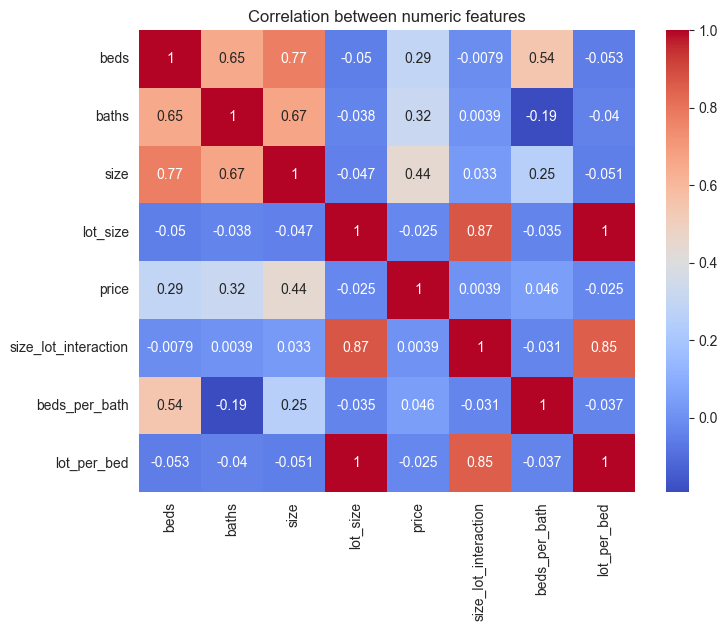

In [30]:
numeric_cols = ['beds', 'baths', 'size', 'lot_size', 'price', 
                'size_lot_interaction', 'beds_per_bath', 'lot_per_bed']

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_train[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between numeric features')
plt.show()

- Heatmap shows pairwise correlation between numeric features.

- Helps identify which features are most strongly associated with price.

- Key insights from the heatmap:

- size and baths are positively correlated with price.

- beds_per_bath, lot_per_bed, lot_size and size_lot_interaction have very weak correlation.

- Correlation informs feature selection and engineering decisions.

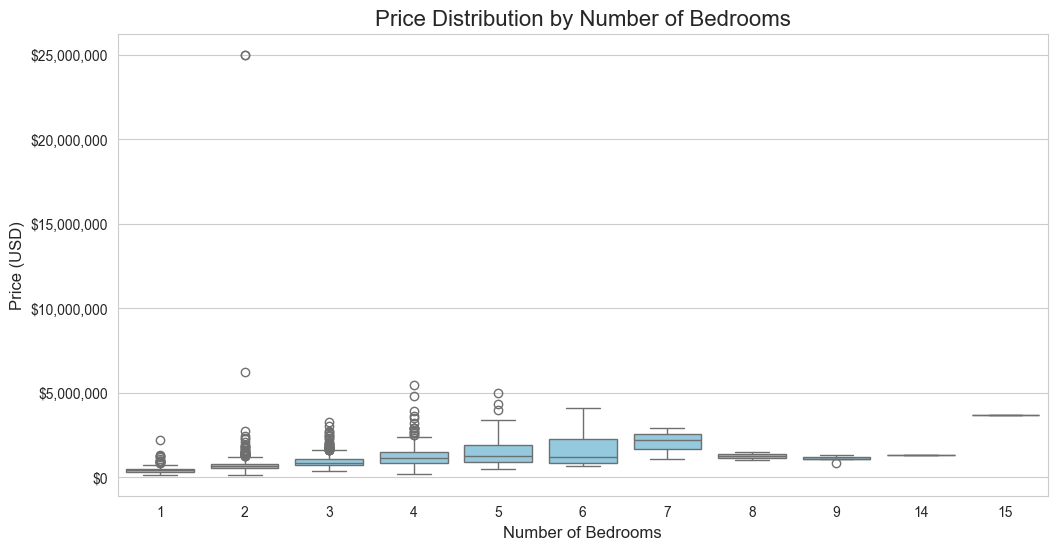

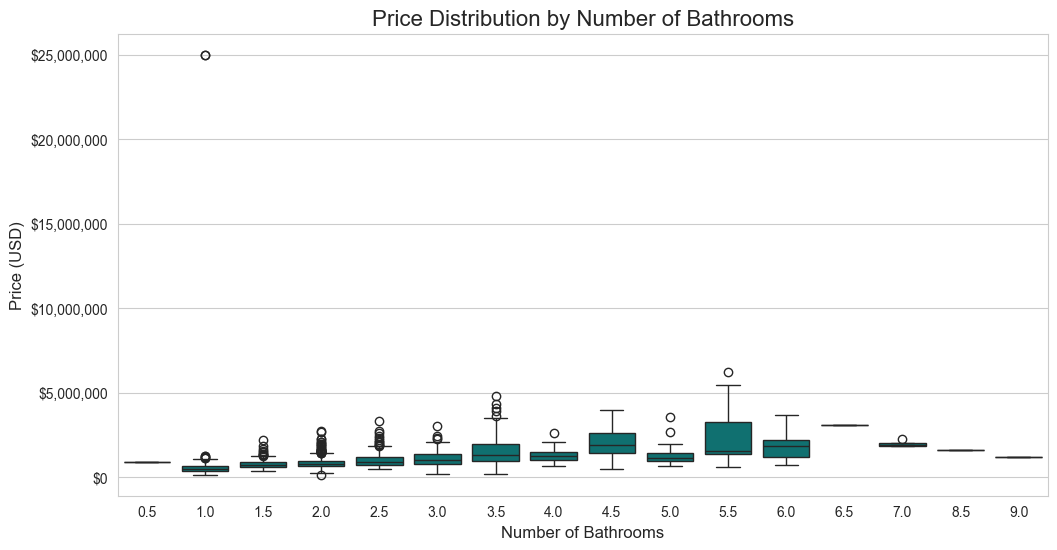

In [32]:

# Bedrooms boxplot
plt.figure(figsize=(12,6))
sns.boxplot(x='beds', y='price', data=df_train, color='skyblue')  # Use color instead of palette
plt.title('Price Distribution by Number of Bedrooms', fontsize=16)
plt.xlabel('Number of Bedrooms', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.show()

# Bathrooms boxplot
plt.figure(figsize=(12,6))
sns.boxplot(x='baths', y='price', data=df_train, color='teal')  # Use color instead of palette
plt.title('Price Distribution by Number of Bathrooms', fontsize=16)
plt.xlabel('Number of Bathrooms', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.show()


- Boxplots show that price generally increases with more bedrooms and bathrooms.
- They also help identify outliers in each category.
- Useful for understanding distribution of discrete features with respect to price.


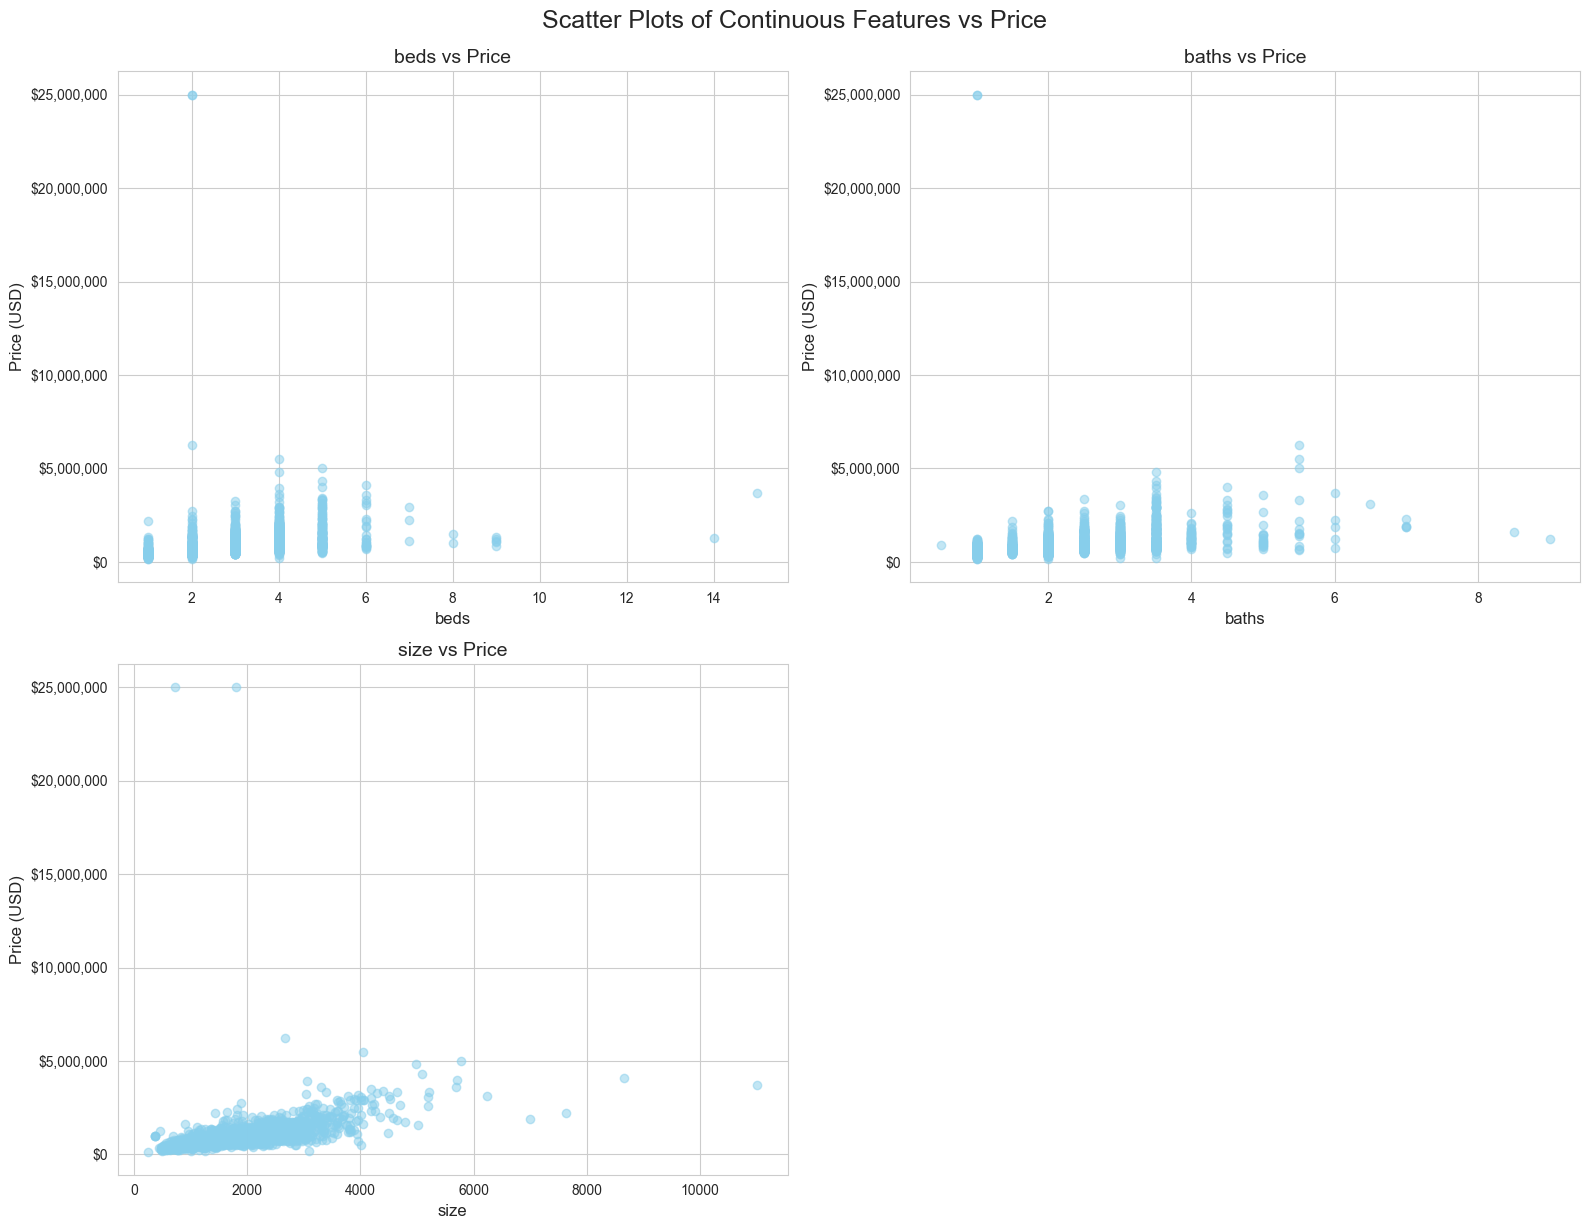

In [34]:

variables = ['beds', 'baths', 'size']
plt.figure(figsize=(16,12))

for i, col in enumerate(variables, 1):
    plt.subplot(2, 2, i)
    plt.scatter(df_train[col], df_train['price'], alpha=0.5, color='skyblue')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Price (USD)', fontsize=12)
    plt.title(f'{col} vs Price', fontsize=14)
    plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.suptitle('Scatter Plots of Continuous Features vs Price', fontsize=18, y=1.02)
plt.show()


- Scatter plots show a positive trend between `beds`, `baths`, `size` and price.
- `lot_size` is omitted here due to almost no correlation.
- Outliers are visible in price; these may be high-end properties that influence linear regression models.


**Summary from this section:**
1. `size`, `baths`, and `beds` are the strongest predictors of price.
2. `lot_size` and engineered ratios (size_lot_interaction, beds_per_bath, lot_per_bed) show very low correlation with price.
3. Price and some continuous features are right-skewed; log transformations improve distribution for linear models.
4. Outliers exist in price, especially for luxury homes.
5. Feature engineering may help non-linear models like Random Forest more than linear models.

<u>**Step 5. Feature Scaling and Data Preparation**</u>

In [38]:
# Drop non-numeric or identifier columns
X = df_train.drop(['price', 'size_units', 'lot_size_units'], axis=1)
y = df_train['price']

# Identify skewed features to log-transform for Linear Regression
skewed_features = ['lot_size', 'size_lot_interaction', 'lot_per_bed']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
#  Random Forest dataset (tree-based models)
# ----------------------------
# Tree-based models do not need log transform or scaling
X_train_rf = X_train.copy()
X_val_rf = X_val.copy()
y_train_rf = y_train.copy()
y_val_rf = y_val.copy()


# ----------------------------
#  Linear Regression dataset
# ----------------------------
# Log-transform skewed features
X_train_lr = X_train.copy()
X_val_lr = X_val.copy()
for col in skewed_features:
    X_train_lr[col] = np.log1p(X_train_lr[col])
    X_val_lr[col] = np.log1p(X_val_lr[col])

# Log-transform target for Linear Regression
y_train_lr = np.log1p(y_train)
y_val_lr = np.log1p(y_val)



scaler = StandardScaler()
X_train_lr_scaled = scaler.fit_transform(X_train_lr)
X_val_lr_scaled = scaler.transform(X_val_lr)


print("Datasets prepared:")
print(f"Random Forest: X_train_rf ({X_train_rf.shape}), y_train_rf ({y_train_rf.shape})")
print(f"Linear Regression: X_train_lr_scaled ({X_train_lr_scaled.shape}), y_train_lr ({y_train_lr.shape})")


Datasets prepared:
Random Forest: X_train_rf ((1612, 7)), y_train_rf ((1612,))
Linear Regression: X_train_lr_scaled ((1612, 7)), y_train_lr ((1612,))


**Summary of this section:**

Split the dataset into training (80%) and validation (20%) sets with X as features and y as target (price).

Log-transform skewed features (lot_size, size_lot_interaction, lot_per_bed) and the target (price) for linear regression to reduce skewness.

Standard scale all features for linear regression; Random Forest does not require scaling or log-transformations.

Prepared two datasets ready for modeling: one tailored for linear regression and another for Random Forest.

<u>**Step 6. Model Training (Linear Regression, Ridge, Lasso & Random Forest)**</u>

In [41]:

# ----------------------------
# Linear Regression
# ----------------------------
lr_model = LinearRegression()
lr_model.fit(X_train_lr_scaled, y_train_lr)

# Predict and inverse log-transform
y_val_pred_lr_log = lr_model.predict(X_val_lr_scaled)
y_val_pred_lr = np.expm1(y_val_pred_lr_log)

# Evaluate
rmse_lr = np.sqrt(mean_squared_error(y_val, y_val_pred_lr))
r2_lr = r2_score(y_val, y_val_pred_lr)
print(f"Linear Regression → RMSE: {rmse_lr:.2f}, R²: {r2_lr:.3f}")


Linear Regression → RMSE: 378252.95, R²: 0.566


In [42]:

# ----------------------------
# Ridge Regression (regularization)
# ----------------------------
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_lr_scaled, y_train_lr)

y_val_pred_ridge = np.expm1(ridge_model.predict(X_val_lr_scaled))
rmse_ridge = np.sqrt(mean_squared_error(y_val, y_val_pred_ridge))
r2_ridge = r2_score(y_val, y_val_pred_ridge)
print(f"Ridge Regression → RMSE: {rmse_ridge:.2f}, R²: {r2_ridge:.3f}")


Ridge Regression → RMSE: 378093.07, R²: 0.567


In [43]:

# ----------------------------
# Lasso Regression (regularization)
# ----------------------------
lasso_model = Lasso(alpha=0.001)
lasso_model.fit(X_train_lr_scaled, y_train_lr)

y_val_pred_lasso = np.expm1(lasso_model.predict(X_val_lr_scaled))
rmse_lasso = np.sqrt(mean_squared_error(y_val, y_val_pred_lasso))
r2_lasso = r2_score(y_val, y_val_pred_lasso)
print(f"Lasso Regression → RMSE: {rmse_lasso:.2f}, R²: {r2_lasso:.3f}")


Lasso Regression → RMSE: 378806.69, R²: 0.565


In [44]:
# ----------------------------
# Random Forest Regressor
# ----------------------------
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

y_val_pred_rf = rf_model.predict(X_val_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val_rf, y_val_pred_rf))
r2_rf = r2_score(y_val_rf, y_val_pred_rf)
print(f"Random Forest → RMSE: {rmse_rf:.2f}, R²: {r2_rf:.3f}")

Random Forest → RMSE: 434652.90, R²: 0.427


**Summary of this section**
- Trained Linear Regression, Ridge, Lasso, and Random Forest models.
- Evaluated performance using RMSE and R² metrics.
- Linear models used scaled and log-transformed features; Random Forest used raw features.

<u>**Step 7. Hyperparameter Tuning and Model Evaluation**</u>

**Linear Regression with Gradient Descent and GridSearchCV**

In [48]:
sgd = SGDRegressor(
    penalty=None,      
    random_state=42
)

param_grid = {
    'eta0': [0.01, 0.05, 0.1, 0.14, 0.2],   # learning rate
    'max_iter': [500, 1000, 2000, 5000],    # number of iterations
    'tol': [1e-3, 1e-4, 1e-5]               # tolerance for stopping
}

grid_sgd = GridSearchCV(
    sgd,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_sgd.fit(X_train_lr_scaled, y_train_lr)

print("Best SGD params:", grid_sgd.best_params_)
print("Best CV RMSE (log-scale):", -grid_sgd.best_score_)

Best SGD params: {'eta0': 0.01, 'max_iter': 500, 'tol': 1e-05}
Best CV RMSE (log-scale): 0.32381273510923986


In [49]:
best_sgd = grid_sgd.best_estimator_
y_val_pred_sgd_log = best_sgd.predict(X_val_lr_scaled)
y_val_pred_sgd = np.expm1(y_val_pred_sgd_log)

rmse_sgd_tuned = np.sqrt(mean_squared_error(y_val, y_val_pred_sgd))
r2_sgd_tuned = r2_score(y_val, y_val_pred_sgd)

print(f"Tuned SGD Linear Regression → RMSE: {rmse_sgd_tuned:.2f}, R²: {r2_sgd_tuned:.3f}")
print(f"Not tuned Linear Regression → RMSE: {rmse_lr:.2f}, R²: {r2_lr:.3f}")


Tuned SGD Linear Regression → RMSE: 376318.01, R²: 0.571
Not tuned Linear Regression → RMSE: 378252.95, R²: 0.566


**Ridge Regression with Gradient Descent and GridSearchCV**

In [51]:
sgd_ridge = SGDRegressor(
    penalty='l2',   # Ridge
    random_state=42
)

# Expanded parameter grid
param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10],
    'eta0': [0.001, 0.01, 0.05, 0.1, 0.2, 0.5],
    'max_iter': [500, 1000, 2000],
    'learning_rate': ['constant', 'optimal', 'invscaling'],
    'tol': [1e-4, 1e-3, 1e-2]
}

# GridSearchCV with 5-fold cross-validation
grid_sgd_ridge = GridSearchCV(
    sgd_ridge,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Fit on training data
grid_sgd_ridge.fit(X_train_lr_scaled, y_train_lr)

# Best hyperparameters
print("Best SGD Ridge params:", grid_sgd_ridge.best_params_)
print("Best CV RMSE (log-scale):", -grid_sgd_ridge.best_score_)


Best SGD Ridge params: {'alpha': 0.001, 'eta0': 0.001, 'learning_rate': 'constant', 'max_iter': 500, 'tol': 0.0001}
Best CV RMSE (log-scale): 0.324744636372805


In [52]:
# Evaluate on validation set
best_sgd_ridge = grid_sgd_ridge.best_estimator_
y_val_pred_sgd_log = best_sgd_ridge.predict(X_val_lr_scaled)
y_val_pred_sgd = np.expm1(y_val_pred_sgd_log)

rmse_sgd = np.sqrt(mean_squared_error(y_val, y_val_pred_sgd))
r2_sgd = r2_score(y_val, y_val_pred_sgd)
print(f"Tuned SGD Ridge → RMSE: {rmse_sgd:.2f}, R²: {r2_sgd:.3f}")
print(f" Not tuned Ridge Regression → RMSE: {rmse_ridge:.2f}, R²: {r2_ridge:.3f}")

Tuned SGD Ridge → RMSE: 374178.21, R²: 0.575
 Not tuned Ridge Regression → RMSE: 378093.07, R²: 0.567


**Lasso Regression GridSearchCV**

In [54]:
sgd_lasso = SGDRegressor(
    penalty='l1',       
    random_state=42
)

param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1],  # regularization strength
    'eta0': [0.01, 0.05, 0.1, 0.14, 0.2],   # learning rate
    'max_iter': [500, 1000, 2000, 5000],    # iterations
    'tol': [1e-3, 1e-4, 1e-5]               # stopping tolerance
}

grid_sgd_lasso = GridSearchCV(
    sgd_lasso,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Fit on training data
grid_sgd_lasso.fit(X_train_lr_scaled, y_train_lr)

# Best hyperparameters
print("Best SGD Lasso params:", grid_sgd_lasso.best_params_)
print("Best CV RMSE (log-scale):", -grid_sgd_lasso.best_score_)

Best SGD Lasso params: {'alpha': 0.0001, 'eta0': 0.01, 'max_iter': 500, 'tol': 1e-05}
Best CV RMSE (log-scale): 0.32383643747434093


In [55]:
best_sgd_lasso = grid_sgd_lasso.best_estimator_
y_val_pred_lasso_log = best_sgd_lasso.predict(X_val_lr_scaled)
y_val_pred_lasso = np.expm1(y_val_pred_lasso_log)

rmse_sgd_lasso = np.sqrt(mean_squared_error(y_val, y_val_pred_lasso))
r2_sgd_lasso = r2_score(y_val, y_val_pred_lasso)

print(f"Tuned SGD Lasso Regression → RMSE: {rmse_sgd_lasso:.2f}, R²: {r2_sgd_lasso:.3f}")
print(f"Not tuned Lasso Regression → RMSE: {rmse_lasso:.2f}, R²: {r2_lasso:.3f}")


Tuned SGD Lasso Regression → RMSE: 376470.67, R²: 0.570
Not tuned Lasso Regression → RMSE: 378806.69, R²: 0.565


**Random Forest Regression GridSearchCV**

In [57]:
rf = RandomForestRegressor(random_state=42)
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
rf_grid.fit(X_train_rf, y_train_rf)

print("Best RF params:", rf_grid.best_params_)
print("Best CV RMSE:", -rf_grid.best_score_)

Best RF params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}
Best CV RMSE: 842669.2856737582


In [58]:
best_rf = rf_grid.best_estimator_

y_val_pred_rf_tuned = best_rf.predict(X_val_rf)

rmse_rf_tuned = np.sqrt(mean_squared_error(y_val_rf, y_val_pred_rf_tuned))
r2_rf_tuned = r2_score(y_val_rf, y_val_pred_rf_tuned)

print(f"Tuned Random Forest → RMSE: {rmse_rf_tuned:.2f}, R²: {r2_rf_tuned:.3f}")
print(f"Untuned Random Forest → RMSE: {rmse_rf:.2f}, R²: {r2_rf:.3f}")

Tuned Random Forest → RMSE: 429446.20, R²: 0.441
Untuned Random Forest → RMSE: 434652.90, R²: 0.427


**Summary of this section:**
- Applied gradient descent with GridSearchCV for Linear, Lasso, and Ridge regression.
- Applied GridSearchCV for hyperparameter tuning of Random Forest regression.
- GridSearchCV helped improve model accuracy by selecting optimal hyperparameters.
- Random Forest regression gave higher error and lower R² compared to the linear models

<u>**Step 8. Feature Important Visualization**</u>

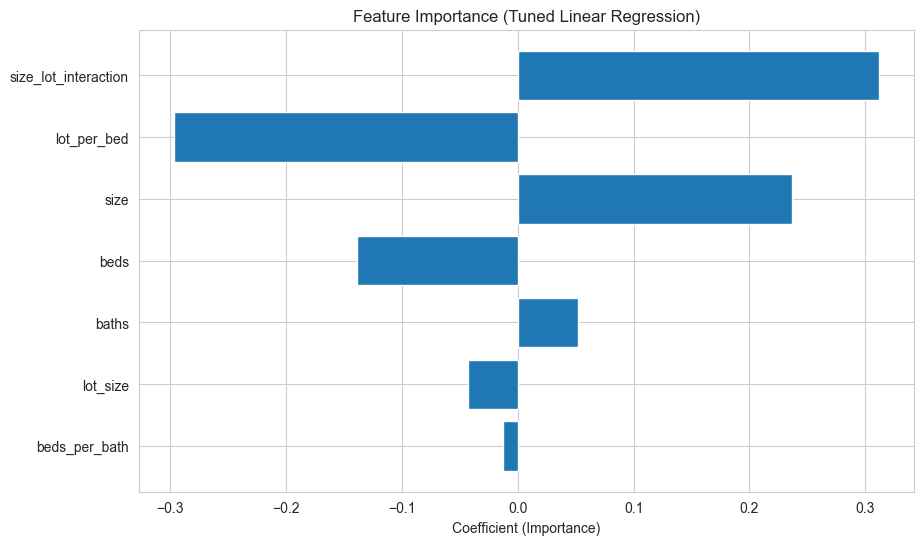

In [61]:
coefs = best_sgd.coef_  
features = X_train_lr.columns

lr_importance_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefs
}).sort_values("Coefficient", key=abs, ascending=False)

plt.figure(figsize=(10,6))
plt.barh(lr_importance_df["Feature"], lr_importance_df["Coefficient"])
plt.xlabel("Coefficient (Importance)")
plt.title("Feature Importance (Tuned Linear Regression)")
plt.gca().invert_yaxis()
plt.show()

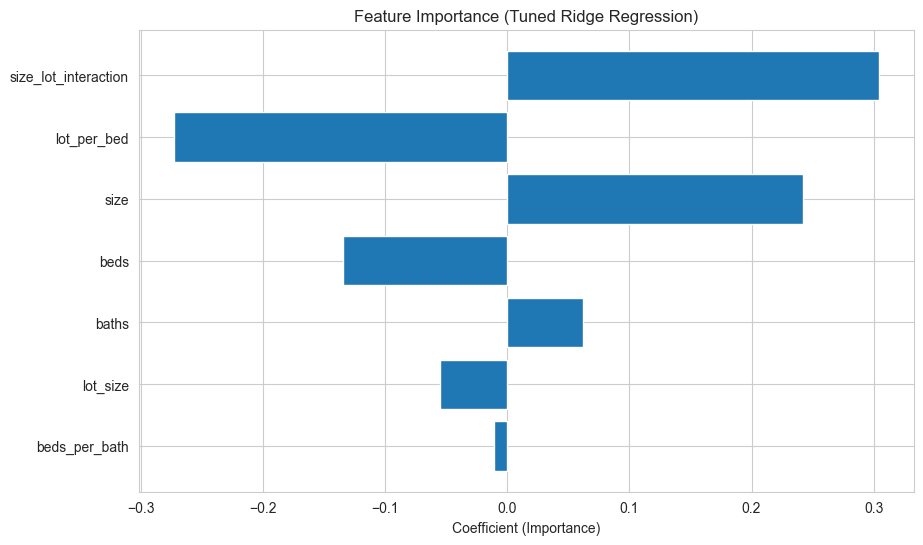

In [62]:
coefs = best_sgd_ridge.coef_  
features = X_train_lr.columns

ridge_importance_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefs
}).sort_values("Coefficient", key=abs, ascending=False)

plt.figure(figsize=(10,6))
plt.barh(ridge_importance_df["Feature"], ridge_importance_df["Coefficient"])
plt.xlabel("Coefficient (Importance)")
plt.title("Feature Importance (Tuned Ridge Regression)")
plt.gca().invert_yaxis()
plt.show()

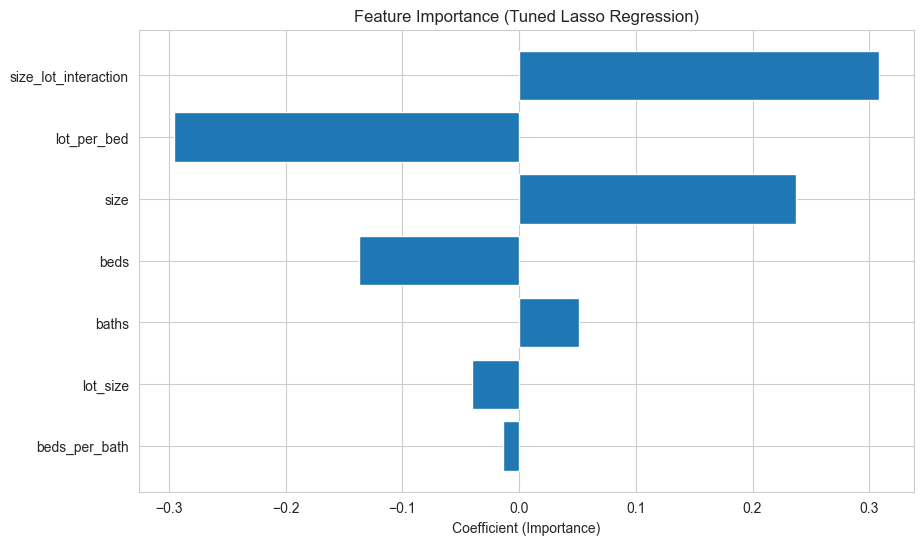

In [63]:
coefs = best_sgd_lasso.coef_  
features = X_train_lr.columns

lasso_importance_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefs
}).sort_values("Coefficient", key=abs, ascending=False)

plt.figure(figsize=(10,6))
plt.barh(lasso_importance_df["Feature"], lasso_importance_df["Coefficient"])
plt.xlabel("Coefficient (Importance)")
plt.title("Feature Importance (Tuned Lasso Regression)")
plt.gca().invert_yaxis()
plt.show()

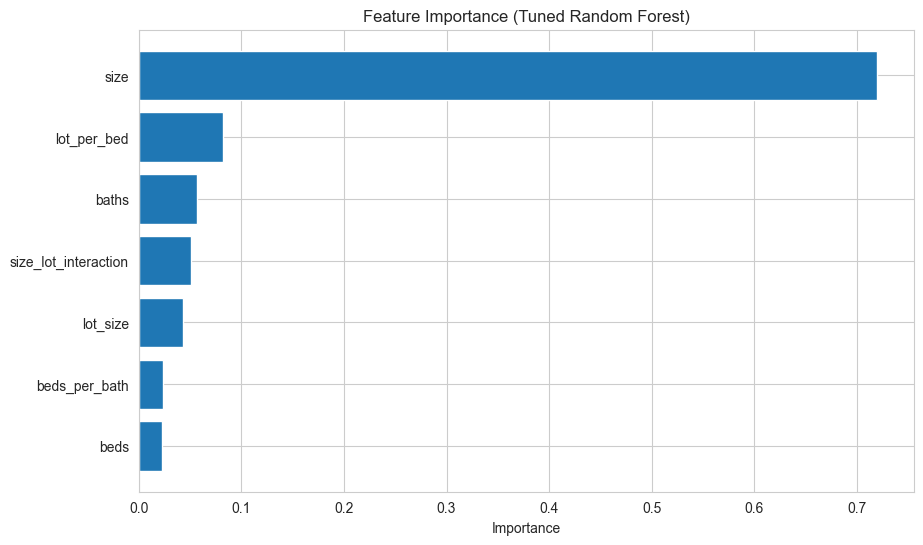

In [64]:
importances = best_rf.feature_importances_
features = X_train_rf.columns

# Create a DataFrame
rf_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(rf_importance_df["Feature"], rf_importance_df["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance (Tuned Random Forest)")
plt.gca().invert_yaxis()
plt.show()

**Summary of this section**
- **size_lot_interaction**, **lot_per_bed** and **size** have the biggest effect on predicting price for lasso, linear and ridge regression.
- **size**, **lot_per_bed** and **baths** have the biggest effect on predicting price for random forest regression.
- Overall **lot_per_bed** and **size** seem to have the biggest and consistent impact on price across all models.

<u>**Step 9. Test Set Predictions**</u>

In [67]:
# Drop non-numeric / ID columns
X_test = df_test.drop(['price', 'size_units', 'lot_size_units'], axis=1)
y_test = df_test['price']

# Make copies for RF (tree-based, no scaling/logging)
X_test_rf = X_test.copy()
y_test_rf = y_test.copy()

# Linear models → log transform skewed features + scaling
X_test_lr = X_test.copy()
for col in ['lot_size', 'size_lot_interaction', 'lot_per_bed']:
    X_test_lr[col] = np.log1p(X_test_lr[col])

y_test_lr = np.log1p(y_test)
X_test_lr_scaled = scaler.transform(X_test_lr)  # use the SAME scaler fitted earlier

In [68]:
# ----------------------------
# Linear Regression (Tuned SGD)
# ----------------------------
y_test_pred_lr_log = best_sgd.predict(X_test_lr_scaled)
y_test_pred_lr = np.expm1(y_test_pred_lr_log)

rmse_lr_test = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
r2_lr_test = r2_score(y_test, y_test_pred_lr)
print(f"Test Linear Regression → RMSE: {rmse_lr_test:.2f}, R²: {r2_lr_test:.3f}")


Test Linear Regression → RMSE: 416317.10, R²: 0.531


In [69]:
# ----------------------------
# Ridge Regression (Tuned SGD)
# ----------------------------
y_test_pred_ridge_log = best_sgd_ridge.predict(X_test_lr_scaled)
y_test_pred_ridge = np.expm1(y_test_pred_ridge_log)

rmse_ridge_test = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
r2_ridge_test = r2_score(y_test, y_test_pred_ridge)
print(f"Test Ridge Regression → RMSE: {rmse_ridge_test:.2f}, R²: {r2_ridge_test:.3f}")

Test Ridge Regression → RMSE: 415335.54, R²: 0.533


In [70]:
# ----------------------------
# Lasso Regression (Tuned SGD)
# ----------------------------
y_test_pred_lasso_log = best_sgd_lasso.predict(X_test_lr_scaled)
y_test_pred_lasso = np.expm1(y_test_pred_lasso_log)

rmse_lasso_test = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))
r2_lasso_test = r2_score(y_test, y_test_pred_lasso)
print(f"Test Lasso Regression → RMSE: {rmse_lasso_test:.2f}, R²: {r2_lasso_test:.3f}")

Test Lasso Regression → RMSE: 416399.97, R²: 0.531


In [71]:
# ----------------------------
# Random Forest (Tuned)
# ----------------------------
y_test_pred_rf = best_rf.predict(X_test_rf)

rmse_rf_test = np.sqrt(mean_squared_error(y_test_rf, y_test_pred_rf))
r2_rf_test = r2_score(y_test_rf, y_test_pred_rf)
print(f"Test Random Forest → RMSE: {rmse_rf_test:.2f}, R²: {r2_rf_test:.3f}")

Test Random Forest → RMSE: 515528.55, R²: 0.281


In [72]:
test_predictions = df_test.copy()

# Add predictions from all models
test_predictions['pred_lr_price'] = y_test_pred_lr
test_predictions['pred_ridge_price'] = y_test_pred_ridge
test_predictions['pred_lasso_price'] = y_test_pred_lasso
test_predictions['pred_rf_price'] = y_test_pred_rf

for col in test_predictions.select_dtypes(include=np.number).columns:
    test_predictions[col] = (test_predictions[col]).round(1)

# Save to CSV
test_predictions.to_csv("test_predictions_all_models.csv", index=False)

print("Test predictions for all models saved to test_predictions_all_models.csv")

Test predictions for all models saved to test_predictions_all_models.csv


**Summary of this section:**
- Tested the 4 models (Linear, Ridge, Lasso and Random Forest Regression on the test data)
- Ridge Regression provided the lowest RMSE
- Random Forest had the highest RMSE